In [ ]:
####################
## ---------
# Author: Ryan Johnson
# Lab: Risca Lab
# Date: 8/31/2026
# ----------
####################

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#####
# below will be two functions.
# one will call the other function, so you just need to put parameters in for the function named ""

In [19]:
# make a function to preprocess the data and make a numpy array with the 10 chunks

def make_chunk_npy(path_to_npy_filex, trial_numberx, nrl_lengthx) :

    path_to_nrl_npy_file = path_to_npy_filex

    trial_number = trial_numberx

    nrl_length = nrl_lengthx

    basename_file = str.split(path_to_nrl_npy_file, sep = "/" )[-1]
    meta_data = str.split(basename_file, sep="_")[3:6]

    #######
    # here I will have modified code that creates the numpy array and probably saves plots to a pdf file

    # making the plot for other trials in nrl 215 (trial 3)

    # flds_215_nrl_12nucs_2kbt_3_trial_full_data = np.load('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_215_nrl_12nucs_2kbt_3_trial.npy')
    fld_loaded_data = np.load(path_to_nrl_npy_file)
    
    # looking at the shapes
    print(np.shape(fld_loaded_data))
    
    print(fld_loaded_data)
    
    # now split without randomizing
    
    nrl_split_chunks = np.array_split(fld_loaded_data, indices_or_sections= 10, axis = 0)
    
    
    # now loop through each chunk and average them
    nrl_split_chunks_avgeraged = []
    
    for x in nrl_split_chunks:
        
        averaged_chunk = np.average(x, axis = 0)
        print("this is in the for loop showing the size of the chunk \n")
        print(np.shape(averaged_chunk))
        nrl_split_chunks_avgeraged.append(averaged_chunk)
    
    
    # first look at the full averaged array
    
    
    print("\n this is the shape of the full averaged array after the for loop \n")
    
    print(np.shape(nrl_split_chunks_avgeraged))
    
    
    # then i need to plot below
    
    num_chunks = 10
    cmap = plt.colormaps['turbo']  # 'turbo' or 'rainbow' work perfectly for sequential time data
    colors = cmap(np.linspace(0, 1, num_chunks))
    
    x_axis = np.arange(50, 50 + len(nrl_split_chunks_avgeraged[0]))
    
    chunk_num = 0
    
    for x in nrl_split_chunks_avgeraged:
        
        plt.plot(x_axis, x, color = colors[chunk_num], label = "this is snapshot average number " + str(chunk_num))
        plt.title("FLD of NRL" + str(nrl_length) + "_" + str(meta_data[0]) + "_" + str(meta_data[1]) + "_" + str(meta_data[2]) +  "_trial (not randomized)")
        plt.xlabel("fragment lengths")
        plt.ylabel("frequency")
        plt.legend(fontsize = 'small')
        chunk_num +=1
    plt.savefig("./all_nrl_165_to_215_results/FLD_of_NRL_" + str(nrl_length) + "_" + str(meta_data[0]) + "_" + str(meta_data[1]) + "_trial_" + str(meta_data[2]) + ".pdf", format = "pdf")
    plt.close()



    # I can call the make_nrl_csv function in this function
    # just pass the chunk_npy file that is created into that function
    # and pass the trial number and nrl length also 

    # calling the other function here
    make_nrl_csv(nrl_split_chunks_avgeraged, trial_number, nrl_length, meta_data)




# now make the function to make the csv

def make_nrl_csv(nrl_chunk_npy, trial_numberx, nrl_lengthx, meta_datax) :

    # now making a csv for hera but 10 different csv's for each chunk of NRL 215

    # modifying this to make the csv where all the chunks are in one file as different columns
    
    # give the trial number
    trial_number = trial_numberx
    nrl_length = nrl_lengthx
    meta_data = meta_datax

    # need x_axis defined here
    x_axis = np.arange(50, 50 + len(nrl_chunk_npy[0]))
    
    new_df = pd.DataFrame()
    new_df['fragment_lengths'] = x_axis
    name_sample = "NRL" + str(nrl_length) + "_" + str(meta_data[0]) + "_" + str(meta_data[1]) + "_trial_" + str(trial_number)
    new_df.insert(0, "sample_name", value = name_sample) 
    
    
    
    chunk_number = 0
    for x in nrl_chunk_npy:
    
        # name_sample = "NRL215_12nucs_2kbt_trial_" + str(trial_number) #+ str(chunk_number)
    
        # new_df = pd.DataFrame()
        new_df['avg_frequency_chunk_' + str(chunk_number) ] = x
        # new_df['fragment_lengths'] = x_axis
        # new_df.insert(0, "sample_name", value = name_sample) 
        # = name_sample
    
        
        # print(new_df)
        
    
        # new_df.to_csv('./' + name_sample + ".csv", sep= ",", index=False)
    
        chunk_number += 1
    
    print(new_df)
    
    # save to a csv
    new_df.to_csv('./all_nrl_165_to_215_results/' + name_sample + ".csv", sep= ",", index=False)

In [ ]:

##################################################
## below this will be examples I used to run the functions, create numpy arrays, create csv files, and plot the FLD

##################################################

In [ ]:
# now checking if the two functions can make what i want

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_215_nrl_12nucs_2kbt_3_trial.npy', 3, 215)

# have to put these all in separate cells for some reason, or the legend will record multiple chunks 

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_215_nrl_12nucs_2kbt_1_trial.npy', 1, 215)

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_215_nrl_12nucs_2kbt_10_trial.npy', 10, 215)


(291, 451)
[[380.63675622 389.83575553 399.30032489 ... 111.44956129 111.37399698
  110.95660439]
 [377.31754226 386.27226756 395.48269081 ...  83.97718433  83.94955574
   83.73334611]
 [375.93267865 384.85722392 394.06827113 ...  89.91680148  90.49570865
   91.1305365 ]
 ...
 [371.21670596 380.01720359 389.08065654 ...  62.41620583  63.23155909
   63.82463653]
 [368.65940109 377.33223891 386.28233857 ...  70.49888938  71.2890533
   71.7263839 ]
 [373.42775595 382.1420731  391.12705016 ...  55.46488183  56.31503933
   56.9847164 ]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for lo

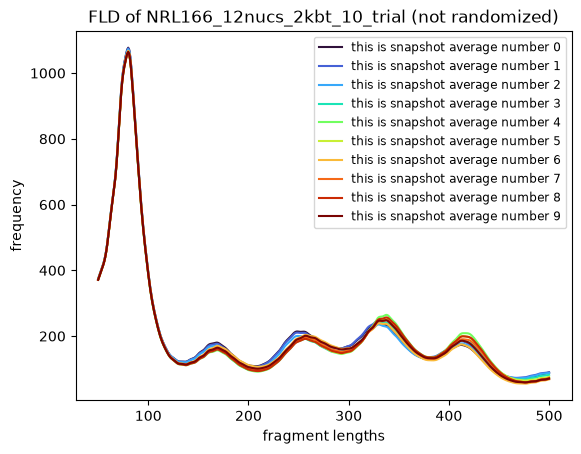

In [7]:

# nrl 166
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_166_nrl_12nucs_2kbt_1_trial.npy', 1 , 166 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_166_nrl_12nucs_2kbt_3_trial.npy', 3, 166)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_166_nrl_12nucs_2kbt_10_trial.npy', 10, 166)



(291, 451)
[[389.89081731 397.99740103 406.41294743 ...  77.6337594   77.75845497
   78.1094971 ]
 [390.7655277  398.95011105 407.47726477 ... 109.62989468 109.86997725
  110.25162484]
 [393.49610819 401.57664736 409.96137845 ...  93.49336483  93.86430506
   94.45679319]
 ...
 [392.95099662 401.21717492 409.83484368 ...  54.5239442   54.92000006
   55.44857792]
 [394.8699532  403.01364156 411.42193515 ...  80.35166247  80.60762494
   80.97707841]
 [396.11657471 404.57718226 413.32287739 ... 134.26266866 136.09074132
  137.98613926]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

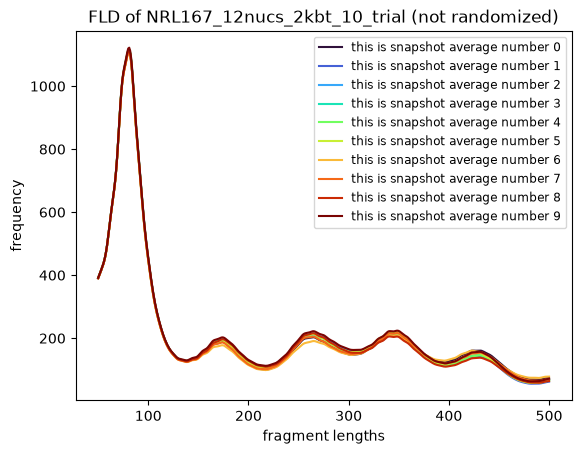

In [10]:
# nrl 167
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_167_nrl_12nucs_2kbt_1_trial.npy', 1 , 167 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_167_nrl_12nucs_2kbt_3_trial.npy', 3, 167)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_167_nrl_12nucs_2kbt_10_trial.npy', 10, 167)



(291, 451)
[[382.34501767 391.26670857 400.43794348 ...  60.92289609  61.24992114
   61.62551499]
 [382.74524456 391.74745819 400.98951508 ...  46.94538721  46.92613351
   47.00671658]
 [380.22916189 389.14795576 398.34319112 ...  53.80149533  53.92287967
   54.18603791]
 ...
 [381.37698753 390.41658722 399.76627504 ...  33.99751403  34.14454169
   34.35160358]
 [385.93154037 395.0457834  404.39832002 ...  59.84917182  59.83075531
   59.8612926 ]
 [385.38284899 394.42443555 403.78084501 ...  35.96625751  36.48424793
   37.04755785]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

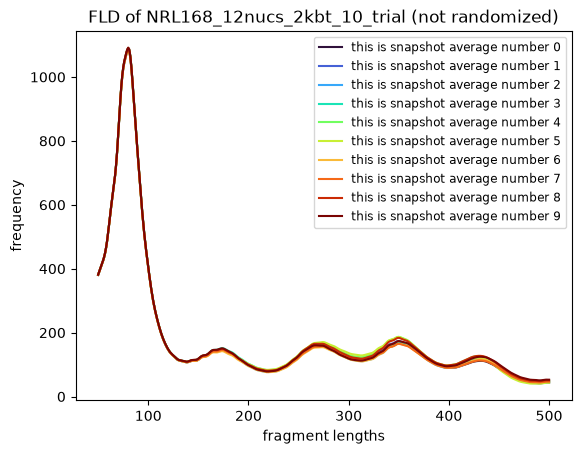

In [13]:
# nrl 168
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_168_nrl_12nucs_2kbt_1_trial.npy', 1 , 168 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_168_nrl_12nucs_2kbt_3_trial.npy', 3, 168)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_168_nrl_12nucs_2kbt_10_trial.npy', 10, 168)



In [ ]:
###############
## now working with different internucleosome potientials (stacking energies)

(191, 451)
[[384.90694106 392.9568037  401.39502435 ...  32.42269903  31.93071447
   31.37415231]
 [393.15333977 401.55531141 410.29225157 ...  86.06743428  86.02585272
   86.04149596]
 [383.68797938 391.6307961  399.91850508 ...  74.31310457  74.13276109
   74.03827319]
 ...
 [387.27135239 395.27932378 403.68301308 ...  52.72231796  51.12365009
   49.64449956]
 [385.86749551 393.93683608 402.37782737 ...  74.66441328  73.62613079
   72.51762336]
 [385.88066813 394.06065306 402.66553173 ...  30.98507944  30.79028238
   30.52549131]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

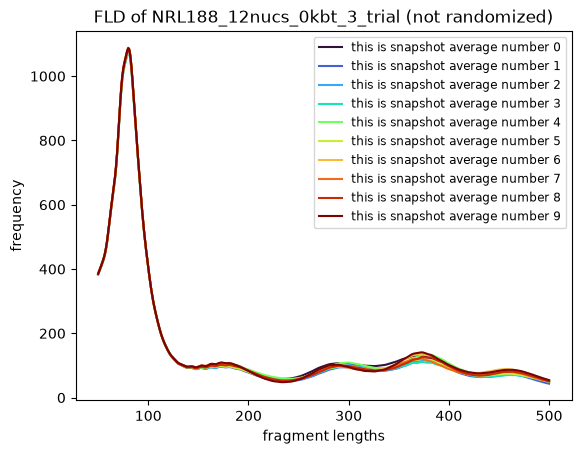

In [5]:
# nrl 188 0kbt
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_0kbt_1_trial.npy', 1, 188)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_0kbt_2_trial.npy', 2, 188)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_0kbt_3_trial.npy', 3, 188)



(191, 451)
[[385.08378579 393.21725847 401.76470676 ...  36.12243673  35.17219116
   34.33338083]
 [383.71659093 391.67599704 400.01328023 ...  68.76976305  68.06954733
   67.40141836]
 [384.45089102 392.3301586  400.61823241 ...  76.94254426  75.28017676
   73.69561916]
 ...
 [385.78214823 393.82818463 402.27452219 ...  23.63484124  22.9656609
   22.34741083]
 [381.50026955 389.41416606 397.77779852 ...  33.51015803  33.46176097
   33.41150929]
 [382.47315055 390.47017466 398.84611399 ...  73.65784167  72.06153994
   70.46846968]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for lo

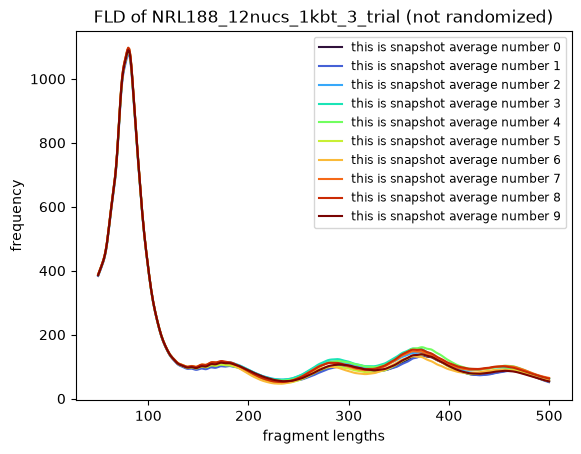

In [8]:
# nrl 188 1kbt
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_1kbt_1_trial.npy', 1, 188)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_1kbt_2_trial.npy', 2, 188)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_1kbt_3_trial.npy', 3, 188)


(191, 451)
[[388.09715    396.15090684 404.5934619  ...  71.59677703  69.29226377
   67.04629536]
 [385.47431029 393.42811406 401.77810428 ...  49.05997071  47.76842405
   46.57128071]
 [383.78207072 391.81077709 400.22262383 ...  45.67080463  44.64660391
   43.67516494]
 ...
 [390.53147026 398.93061248 407.76488923 ...  64.55320049  63.68829184
   62.8559144 ]
 [388.01549183 396.37991083 405.13660794 ...  64.12843418  62.82544228
   61.59116863]
 [387.49194194 395.78921785 404.49642187 ...  57.81496648  56.51174856
   55.3080594 ]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

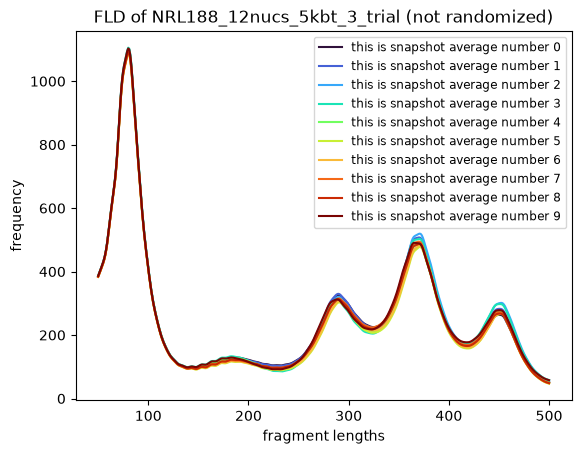

In [11]:
# nrl 188 5kbt
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_5kbt_1_trial.npy', 1, 188)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_5kbt_2_trial.npy', 2, 188)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_5kbt_3_trial.npy', 3, 188)


(191, 451)
[[393.0917404  401.29057138 409.86285066 ... 110.97626417 109.68845712
  107.8866346 ]
 [395.72667484 403.94605606 412.54027009 ... 118.15091304 116.41068133
  114.70529164]
 [392.97105947 401.29148035 409.96880596 ... 128.31709713 126.45944516
  124.83077512]
 ...
 [397.85892597 406.31001036 415.19415166 ... 159.13631497 158.66525666
  158.19454816]
 [397.88688504 406.40799014 415.37281595 ... 161.75358699 161.49817726
  161.25605627]
 [394.77391075 403.10708764 411.87872448 ... 159.75945847 159.08382854
  158.39554122]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

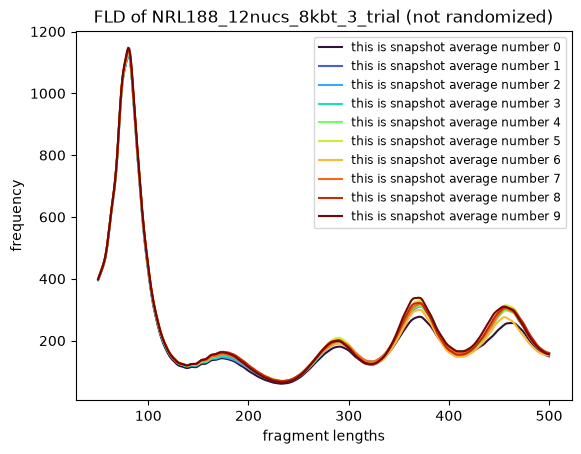

In [14]:
# nrl 188 8kbt
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_8kbt_1_trial.npy', 1, 188)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_8kbt_2_trial.npy', 2, 188)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/scaling_internuc_potential/188_nrl/flds_188_nrl_12nucs_8kbt_3_trial.npy', 3, 188)


(291, 451)
[[386.36944764 394.35848378 402.68183681 ...  27.05155258  27.49145908
   28.00288899]
 [397.74935759 406.1369007  414.89436541 ...  72.62397235  73.30778282
   74.20329862]
 [387.28660272 395.08709492 403.24451087 ...  52.26410228  52.05801296
   52.03651275]
 ...
 [390.69226328 398.75626907 407.19834319 ...  60.42389101  60.46374972
   60.65059181]
 [390.61232472 398.79337523 407.2801174  ...  25.98609376  25.95999738
   26.01227477]
 [395.78841221 403.91493523 412.37658599 ...  30.4379736   30.67627946
   30.99868069]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

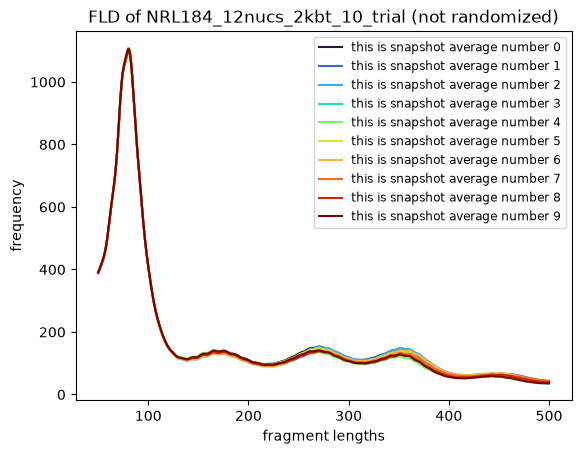

In [5]:
# back to the different nrls

# nrl 184
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_184_nrl_12nucs_2kbt_1_trial.npy', 1 , 184 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_184_nrl_12nucs_2kbt_3_trial.npy', 3, 184)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_184_nrl_12nucs_2kbt_10_trial.npy', 10, 184)


(291, 451)
[[390.11693928 397.89596101 406.02096397 ...  51.05562438  50.11603472
   49.26962418]
 [400.64335454 409.12311087 417.96396931 ...  63.18151623  62.9639908
   62.82675436]
 [401.35589446 409.79298665 418.56719186 ...  64.93390354  64.36919919
   64.00317671]
 ...
 [397.3734784  405.45231861 413.87947156 ...  64.3875479   64.46243011
   64.60472358]
 [397.82027897 406.00131148 414.51912926 ...  73.9146189   73.0914574
   72.42360254]
 [392.76944494 400.82428468 409.20580896 ...  90.28765243  88.9954034
   87.88698563]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop

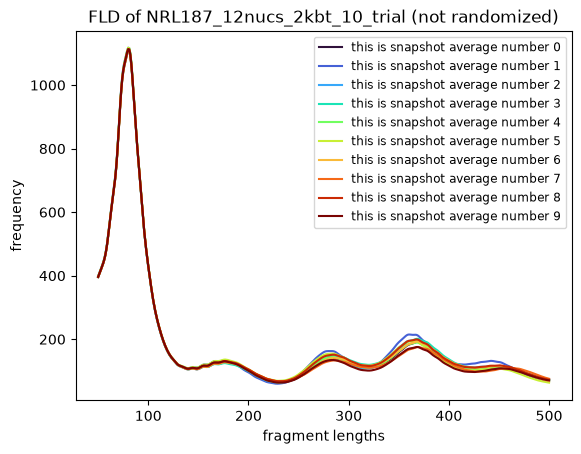

In [8]:
# nrl 187
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_187_nrl_12nucs_2kbt_1_trial.npy', 1 , 187 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_187_nrl_12nucs_2kbt_3_trial.npy', 3, 187)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_187_nrl_12nucs_2kbt_10_trial.npy', 10, 187)

(291, 451)
[[392.79855445 400.34384094 408.22779645 ...  24.8805153   24.65961189
   24.49395376]
 [402.78449603 410.65934017 418.81446228 ...  47.87611229  48.05449567
   48.34791068]
 [390.20457694 397.63225616 405.37164117 ...  16.45427302  16.11811859
   15.84465496]
 ...
 [395.37741425 402.94820926 410.87015876 ...  34.96640622  34.61818758
   34.3427156 ]
 [394.41877058 402.01338379 409.97320586 ...  74.47434328  73.83051372
   73.32774223]
 [399.03747681 406.78452398 414.86435805 ...  71.38993507  71.59168268
   72.01680111]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for l

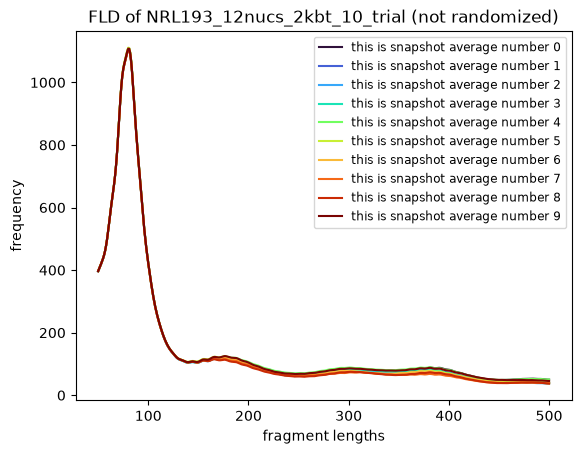

In [11]:
# nrl 193
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_193_nrl_12nucs_2kbt_1_trial.npy', 1 , 193 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_193_nrl_12nucs_2kbt_3_trial.npy', 3, 193)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_193_nrl_12nucs_2kbt_10_trial.npy', 10, 193)

(291, 451)
[[386.71526384 394.95232037 403.61488155 ...  32.19737334  32.68011326
   33.27224836]
 [388.67334334 397.21516231 406.18733182 ...  36.30941082  36.19032079
   36.05881532]
 [392.40787209 400.88618657 409.79955372 ...  97.53358775  97.20814116
   96.66615643]
 ...
 [393.67260117 402.0536519  410.83956324 ...  49.79087546  49.09662714
   48.3866644 ]
 [390.88330685 399.14649672 407.84412016 ...  45.8279405   44.99836795
   44.18768052]
 [387.92873648 396.19214931 404.87773587 ...  22.80238409  22.2869689
   21.71988778]]
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for loop showing the size of the chunk 

(451,)
this is in the for lo

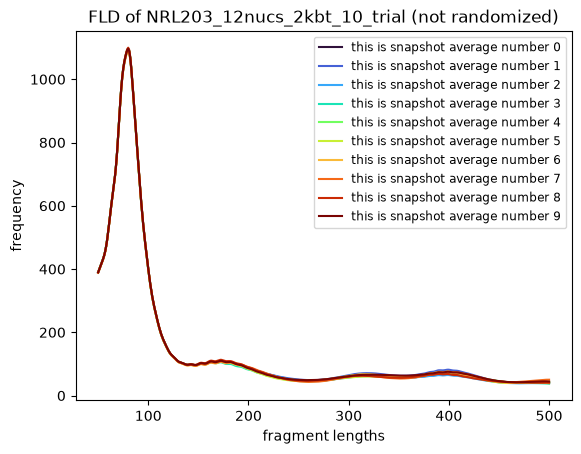

In [14]:
# nrl 203
# make_chunk_npy('', , )

# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_203_nrl_12nucs_2kbt_1_trial.npy', 1 , 203 )
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_203_nrl_12nucs_2kbt_3_trial.npy', 3, 203)
# make_chunk_npy('/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_203_nrl_12nucs_2kbt_10_trial.npy', 10, 203)

In [20]:
## 

# since the nrl's go from 165 to 215 with no gaps, I can automate a for loop to create a string that plugs that nrl into the file name

# first make a range of numbers
# I want the range to include 215
nrl_lengths = np.arange(165,215+1)
print(nrl_lengths)

trial_num = [1,3,10]
print(trial_num)

# for loop to run the data for each nrl length

for nrl in nrl_lengths:

    # get path to the data
    data_path = "/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/"
    
    for trial in trial_num:
        # concatenate the current nrl into the file name
        
        file_name = "flds_"+ str(nrl) +"_nrl_12nucs_2kbt_"+ str(trial) +"_trial.npy"
        print(file_name)

        # concatenate the path to the file name
        full_data_path = data_path + file_name
        print(full_data_path)

        # now can call the function with the nrl and trial num also!!
        # path, trial, nrl
        make_chunk_npy(full_data_path, trial, nrl)

        

[165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182
 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215]
[1, 3, 10]
flds_165_nrl_12nucs_2kbt_1_trial.npy
/ru-auth/local/home/abrenner/mystore/meso_wlc_manuscript_data/intermed_data/flds/nrls_165_to_215/flds_165_nrl_12nucs_2kbt_1_trial.npy
(291, 451)
[[381.99080342 391.21585297 400.75472135 ...  70.25596632  69.47702303
   68.52660653]
 [375.96812617 385.0074371  394.34412979 ...  50.61005365  50.54396995
   50.45588509]
 [372.03713947 380.9833073  390.23454556 ...  87.68009953  87.86435696
   87.92337124]
 ...
 [368.39034489 376.98464932 385.89178361 ...  72.17071156  72.55145913
   72.82123924]
 [373.82726432 382.67203453 391.84104188 ...  86.82980425  86.61164443
   86.37434392]
 [370.85698404 379.70233299 388.85967646 ...  53.75965586  53.67060266
   53.30364595]]
this is in the for loop showing the size of the chunk 

(451,)
this is 